# AI-Powered Smart Retail & Customer Intelligence Platform

## Module 1: Product Image Classification using Fashion-MNIST

---

## 1. Introduction

## 2. Project Objective

## 3. Import Required Libraries

## 4. Mount Google Drive

## 5. Load Fashion-MNIST Dataset

## 6. Explore the Dataset

## 7. Data Preprocessing

## 8. Data Visualization

## 9. Build Deep Learning Model

## 10. Train the Model

## 11. Evaluate the Model

## 12. Save the Model

## 13. Test the Model

## 14. Conclusion

## Introduction

Image classification is one of the most widely used applications of Computer Vision. It enables computers to automatically identify and classify objects present in an image.

In this module, we develop a deep learning model capable of classifying fashion products into predefined categories using the Fashion-MNIST dataset. This model serves as the product classification component of the AI-Powered Smart Retail & Customer Intelligence Platform.

## Project Objective

The objective of this module is to build a deep learning image classification model that automatically predicts the category of a fashion product from its image. The trained model will later be integrated into a FastAPI application to classify uploaded product images in real time.

In [5]:
# Numerical Computing
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# TensorFlow
import tensorflow as tf

# Dataset Loader
from tensorflow.keras.datasets import fashion_mnist

# Utility Functions
from tensorflow.keras.utils import to_categorical

# Print TensorFlow Version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


## Dataset Description

The Fashion-MNIST dataset is a benchmark dataset consisting of grayscale images of fashion products.

It contains 70,000 images divided into ten categories.

Training Images : 60,000

Testing Images : 10,000

Image Size : 28 × 28 pixels

Color Channels : Grayscale

In [8]:
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

for i, name in enumerate(class_names):
    print(i, ":", name)

0 : T-shirt/Top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle Boot


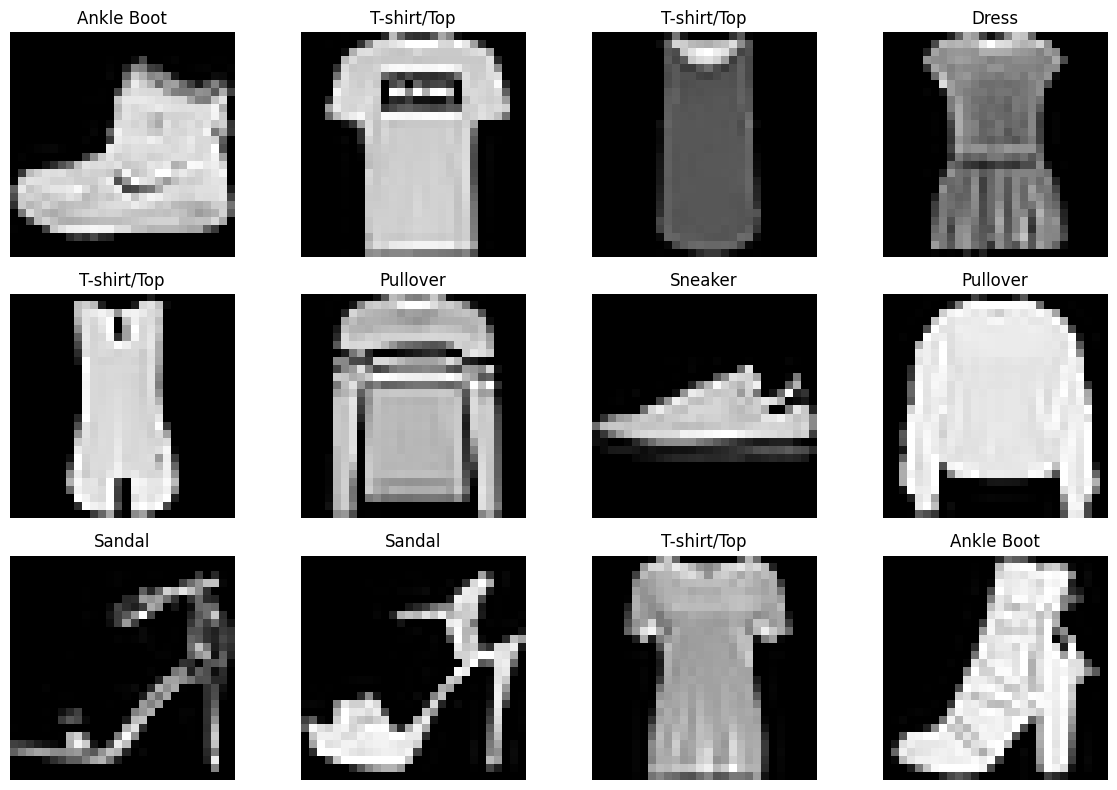

In [9]:
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(class_names[y_train[i]])

    plt.axis('off')

plt.tight_layout()

plt.show()

## 7. Data Preprocessing

Before training the model, the image data is analyzed and prepared by checking its dimensions, data type, and pixel value range.

In [10]:
print("Training Image Shape :", X_train.shape)
print("Testing Image Shape :", X_test.shape)

print("\nData Type :", X_train.dtype)

print("\nMinimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Training Image Shape : (60000, 28, 28)
Testing Image Shape : (10000, 28, 28)

Data Type : uint8

Minimum Pixel Value : 0
Maximum Pixel Value : 255


In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [12]:
print("Minimum Pixel :", X_train.min())
print("Maximum Pixel :", X_train.max())

Minimum Pixel : 0.0
Maximum Pixel : 1.0


In [13]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [14]:
print(y_train_cat.shape)
print(y_test_cat.shape)

(60000, 10)
(10000, 10)


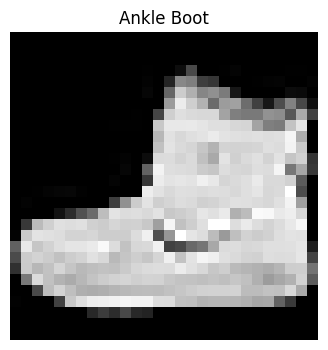

In [15]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0], cmap='gray')
plt.title(class_names[y_train[0]])
plt.axis('off')
plt.show()

### Data Preprocessing Summary

The following preprocessing steps were performed before model training:

- Checked image dimensions and pixel value range.
- Converted image data type from `uint8` to `float32`.
- Normalized pixel values from the range **0–255** to **0–1**.
- Converted class labels into one-hot encoded vectors for multi-class classification.

These preprocessing steps help improve model convergence and classification performance.

In [16]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


## 9. Build Deep Learning Model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [18]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,
                 kernel_size=(3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64,
                 kernel_size=(3,3),
                 activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Convert Feature Maps into Vector
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,
                activation='relu'))

# Prevent Overfitting
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10,
                activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Compile the Model

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=64
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7993 - loss: 0.5481 - val_accuracy: 0.8589 - val_loss: 0.3856
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8695 - loss: 0.3632 - val_accuracy: 0.8806 - val_loss: 0.3222
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8857 - loss: 0.3144 - val_accuracy: 0.8885 - val_loss: 0.3070
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8959 - loss: 0.2853 - val_accuracy: 0.8917 - val_loss: 0.2892
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9031 - loss: 0.2613 - val_accuracy: 0.9014 - val_loss: 0.2631
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9106 - loss: 0.2421 - val_accuracy: 0.9025 - val_loss: 0.2684
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9161 - loss: 0.2253 - val_accuracy: 0.9083 - val_loss: 0.2474
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9208 - loss: 0.2108 - val_accuracy: 0

## 11. Model Evaluation

The model performance is evaluated using training and validation accuracy and loss curves.

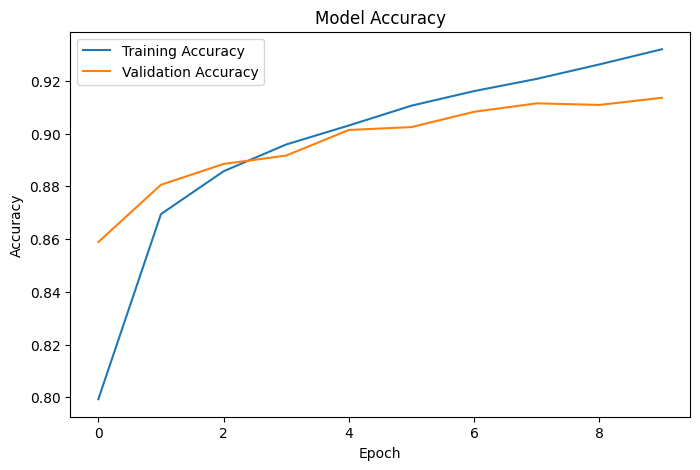

In [22]:
# Plot Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

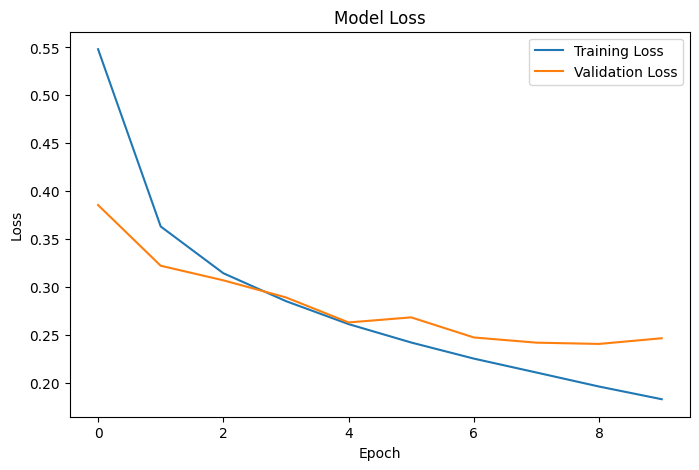

In [23]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9136 - loss: 0.2466
Test Loss: 0.2466
Test Accuracy: 0.9136


In [25]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


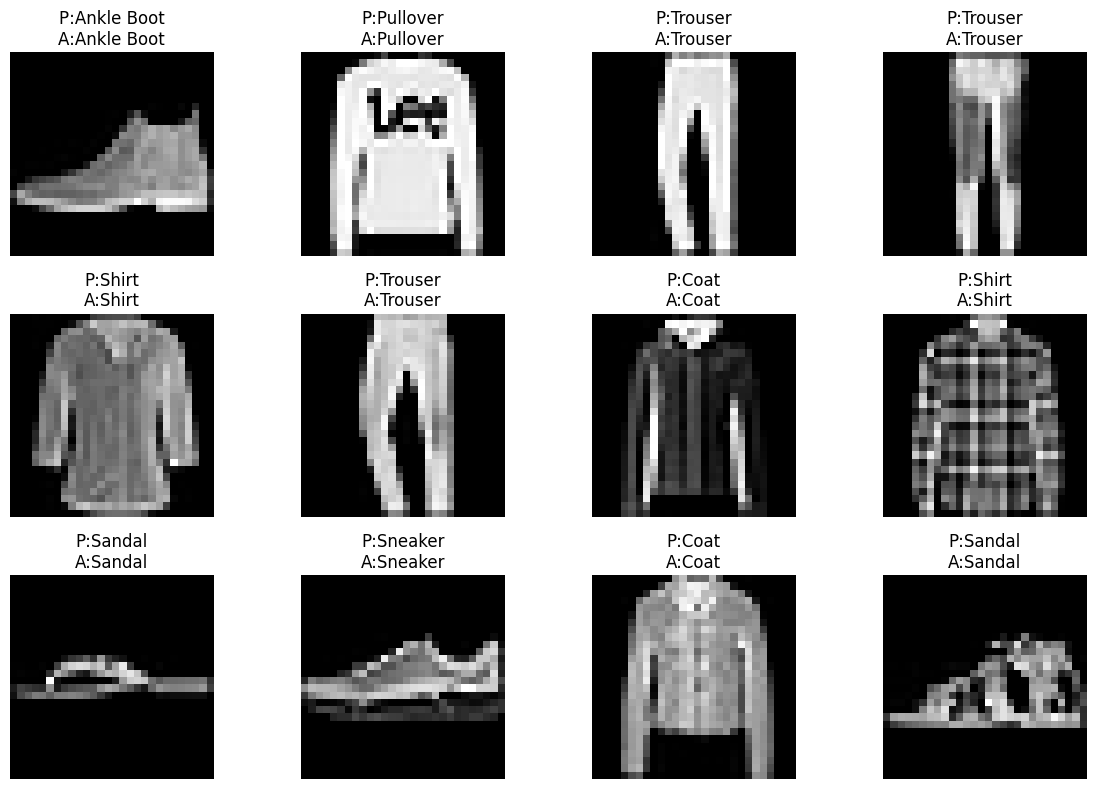

In [26]:
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    predicted = np.argmax(predictions[i])

    actual = y_test[i]

    plt.title(f"P:{class_names[predicted]}\nA:{class_names[actual]}")

    plt.axis('off')

plt.tight_layout()

plt.show()

<Figure size 1000x1000 with 0 Axes>

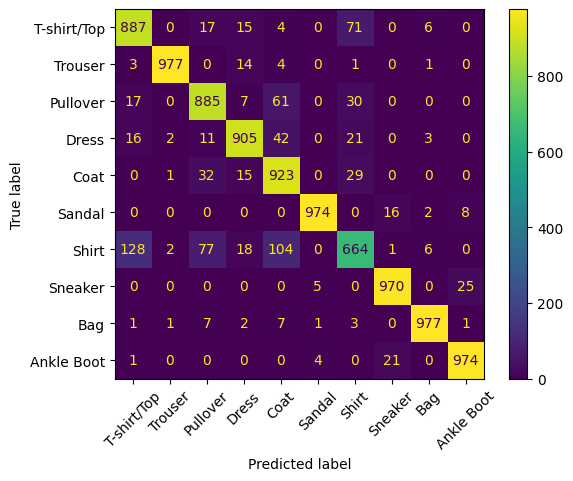

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

plt.figure(figsize=(10,10))

disp.plot(xticks_rotation=45)

plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.89      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.89      0.87      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.81      0.92      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.81      0.66      0.73      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [29]:
import os

model_dir = "/content/drive/MyDrive/Smart-Retail-AI/models"

os.makedirs(model_dir, exist_ok=True)

model.save(os.path.join(model_dir, "product_classifier.keras"))

print("Model saved successfully!")

Model saved successfully!


## Conclusion

A Convolutional Neural Network (CNN) was developed to classify fashion product images using the Fashion-MNIST dataset.

The model achieved a training accuracy of approximately **93.2%** and a validation accuracy of approximately **91.4%**, demonstrating strong performance on unseen data.

The trained model will be integrated into the Smart Retail & Customer Intelligence Platform to provide automated product classification through REST APIs.